In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, f1_score


2026-04-15 20:11:52.403317: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df = pd.read_csv("", sep=None, engine="python")
df.shape

X = df.drop(columns=["is_alarm"])
y = df["is_alarm"]

X = X.select_dtypes(include=[np.number])


data = pd.concat([X, y], axis=1).dropna()
X = data.drop(columns=["is_alarm"])
y = data["is_alarm"]

print("Clean shape:", X.shape)

Clean shape: (21625, 30)


SPLIT (train / val / test)

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

Scaling

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Class Weights

In [5]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i: w for i, w in enumerate(weights)}

print("Class weights:", class_weights)

Class weights: {0: 16.78159645232816, 1: 0.5153547596350265}


In [6]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)


Training

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
237/237 [==============================] - 4s 6ms/step - loss: 0.8719 - accuracy: 0.5061 - auc: 0.5423 - val_loss: 0.8064 - val_accuracy: 0.3221 - val_auc: 0.5183
Epoch 2/30
237/237 [==============================] - 1s 5ms/step - loss: 0.7782 - accuracy: 0.5424 - auc: 0.5677 - val_loss: 0.7186 - val_accuracy: 0.5049 - val_auc: 0.5544
Epoch 3/30
237/237 [==============================] - 1s 4ms/step - loss: 0.7342 - accuracy: 0.5565 - auc: 0.5901 - val_loss: 0.7221 - val_accuracy: 0.5644 - val_auc: 0.5614
Epoch 4/30
237/237 [==============================] - 1s 4ms/step - loss: 0.7019 - accuracy: 0.5625 - auc: 0.6220 - val_loss: 0.6635 - val_accuracy: 0.6424 - val_auc: 0.5652
Epoch 5/30
237/237 [==============================] - 1s 4ms/step - loss: 0.6973 - accuracy: 0.5829 - auc: 0.6146 - val_loss: 0.6528 - val_accuracy: 0.6030 - val_auc: 0.5921
Epoch 6/30
237/237 [==============================] - 1s 4ms/step - loss: 0.6747 - accuracy: 0.6014 - auc: 0.6402 - val_loss: 0.67

In [8]:
y_val_prob = model.predict(X_val).ravel()

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []

for t in thresholds:
    preds = (y_val_prob >= t).astype(int)
    f1_scores.append(f1_score(y_val, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
print("Best threshold:", best_threshold)

102/102 [==============================] - 0s 1ms/step
Best threshold: 0.1


Test Evaluation

In [9]:
y_test_prob = model.predict(X_test).ravel()
y_pred = (y_test_prob >= best_threshold).astype(int)

print("\nClassification report:")
print(classification_report(y_test, y_pred))

102/102 [==============================] - 0s 1ms/step

Classification report:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        97
         1.0       0.97      1.00      0.98      3147

    accuracy                           0.97      3244
   macro avg       0.49      0.50      0.49      3244
weighted avg       0.94      0.97      0.96      3244


/Users/mac/Downloads/Python/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/mac/Downloads/Python/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/mac/Downloads/Python/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Confusion Matrix

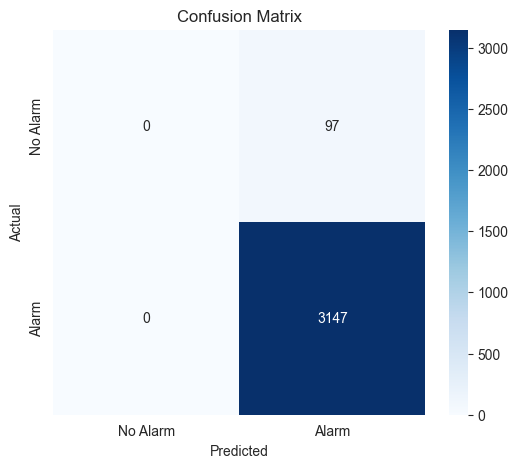

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Alarm', 'Alarm'],
            yticklabels=['No Alarm', 'Alarm'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC/PR Curve

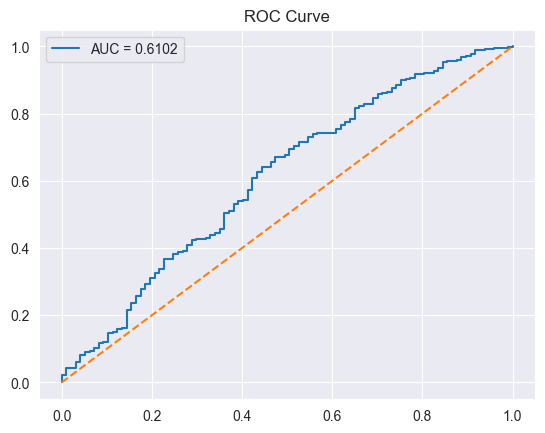

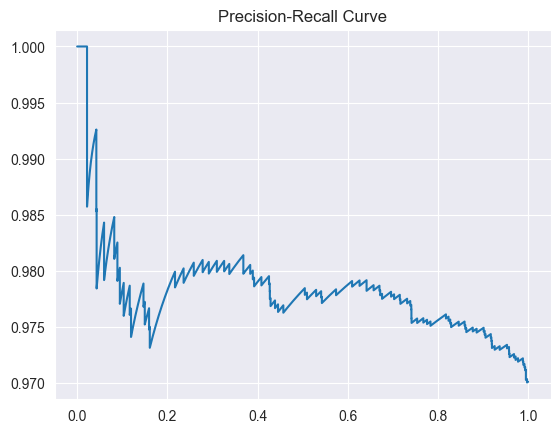

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.legend()
plt.show()


# PR CURVE
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)

plt.figure()
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.show()

Training history

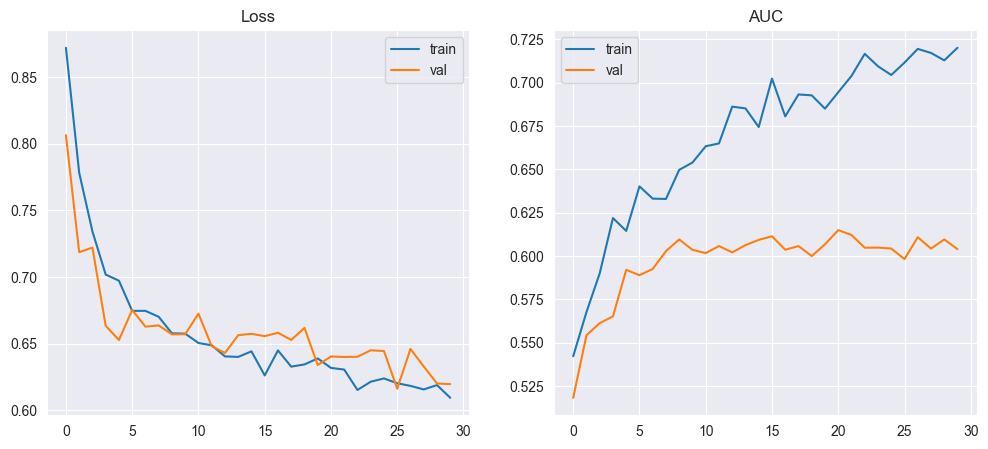

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='train')
plt.plot(history.history['val_auc'], label='val')
plt.title("AUC")
plt.legend()

plt.show()

Single Prediction

In [13]:
sample = X_test[0].reshape(1, -1)

prob = model.predict(sample)[0][0]
pred_class = int(prob >= best_threshold)

print("\nSingle prediction:")
print(f"Probability: {prob:.4f}")
print(f"Class: {pred_class}")

1/1 [==============================] - 0s 23ms/step

Single prediction:
Probability: 0.2304
Class: 1
